⏳ 1. Memuat Data Training (Hasil Split Tahap 04)...
⏳ 2. Menjalankan Algoritma MLSMOTE (Fokus Minoritas)...
-> Ditemukan 10318 responden di kelompok minoritas untuk digandakan.


d:\Amikom\Semester 6\Project Data Mining\Project\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
d:\Amikom\Semester 6\Project Data Mining\Project\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
d:\Amikom\Semester 6\Project Data Mining\Project\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
d:\Amikom\Semester 6\Project Data Mining\Project\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
d:\Amikom\Semester 6\Project Data Mining\Project\venv\lib\site-packages\sklearn\utils\validation.py:2749


    ### ⚖️ Tahap 05: Multi-label Imbalance Handling Selesai
    ---
    Teknik **MLSMOTE** telah diterapkan untuk memperkuat representasi kelas minoritas pada ketiga label sekaligus tanpa merusak korelasi antar label.

    **Statistik Perubahan:**
    * Jumlah Data Awal: **21,740** baris.
    * Jumlah Data Setelah MLSMOTE: **36,740** baris.
    * Penambahan Data Sintetis: +15,000 baris.

    ✅ *Data training yang seimbang kini tersedia di `train_balanced_multilabel.csv`. Siap untuk seleksi fitur MFO.*
    

🎨 Membuat Visualisasi Perbandingan Distribusi Kelas...


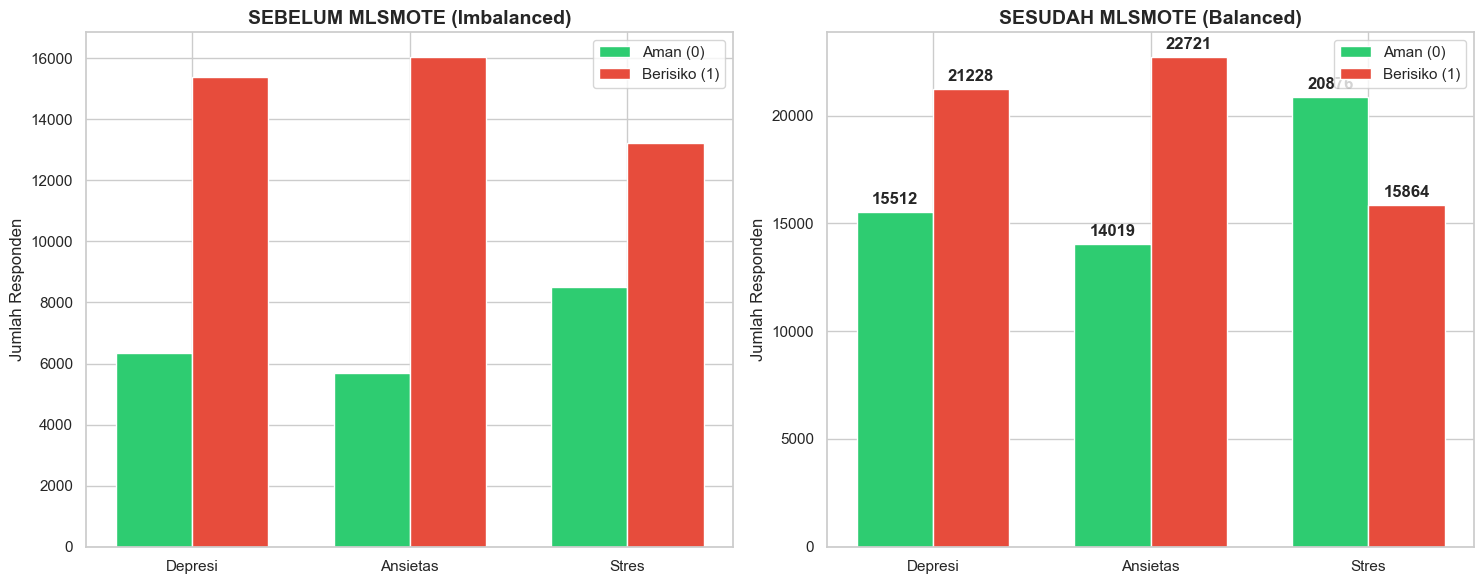

✅ Visualisasi berhasil disimpan di folder 'outputs/imbalance_figures/' dan di-log ke MLflow.


In [3]:
import pandas as pd
import numpy as np
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.neighbors import NearestNeighbors
from IPython.display import display, Markdown

# ==========================================
# 1. SETUP PATH & MLFLOW
# ==========================================
root_path = Path.cwd().parent
mlflow.set_tracking_uri((root_path / "mlruns").as_uri())
mlflow.set_experiment("05_Multi_label_Imbalance")

# Fungsi MLSMOTE Revisi: Fokus Oversampling pada Kelas Minoritas
def get_mlsmote_minority(X, y, n_synthetic):
    n_neighbors = 5
    nn = NearestNeighbors(n_neighbors=n_neighbors)
    nn.fit(X)
    
    new_X = []
    new_y = []
    
    # 1. IDENTIFIKASI MINORITAS
    # Kita cari index baris di mana responden berstatus 'Aman' (0) 
    # di setidaknya satu kondisi mental.
    minority_mask = (y['risk_depression'] == 0) | (y['risk_anxiety'] == 0) | (y['risk_stress'] == 0)
    minority_indices = y[minority_mask].index.tolist()
    
    print(f"-> Ditemukan {len(minority_indices)} responden di kelompok minoritas untuk digandakan.")
    
    # 2. GENERASI DATA SINTETIS KHUSUS DARI MINORITAS
    for i in range(n_synthetic):
        # Pilih secara acak HANYA dari index minoritas
        idx = np.random.choice(minority_indices)
        
        # Karena kita memotong data sebelumnya, kita pastikan kita mengambil posisi baris (iloc)
        # Kita harus mencari posisi integer (iloc) dari label index (loc)
        iloc_idx = X.index.get_loc(idx)
        
        sample_x = X.iloc[iloc_idx].values
        sample_y = y.iloc[iloc_idx].values
        
        # Cari tetangga terdekat dari sampel minoritas ini
        neighbors = nn.kneighbors([sample_x], return_distance=False)[0]
        neighbor_idx = np.random.choice(neighbors)
        neighbor_x = X.iloc[neighbor_idx].values
        
        # Interpolasi (Membuat kloning di antara dua titik)
        diff = neighbor_x - sample_x
        step = np.random.uniform(0, 1)
        gen_x = sample_x + step * diff
        
        new_X.append(gen_x)
        new_y.append(sample_y)

    return pd.DataFrame(new_X, columns=X.columns), pd.DataFrame(new_y, columns=y.columns)

with mlflow.start_run(run_name="MLSMOTE_Augmentation"):
    print("⏳ 1. Memuat Data Training (Hasil Split Tahap 04)...")
    train_df = pd.read_csv(root_path / "Data/split/train_data.csv")
    
    target_cols = ['risk_depression', 'risk_anxiety', 'risk_stress']
    X_train = train_df.drop(columns=target_cols)
    Y_train = train_df[target_cols]

    # ==========================================
    # 2. PROSES MLSMOTE (DIREVISI)
    # ==========================================
    print("⏳ 2. Menjalankan Algoritma MLSMOTE (Fokus Minoritas)...")
    
    # Menambahkan 15.000 data sintetis untuk mendongkrak kelas 'Aman'
    n_synthetic = 15000 
    X_res, Y_res = get_mlsmote_minority(X_train, Y_train, n_synthetic)
    
    # Gabungkan data asli dengan data sintetis
    X_train_final = pd.concat([X_train.reset_index(drop=True), X_res.reset_index(drop=True)], axis=0).reset_index(drop=True)
    Y_train_final = pd.concat([Y_train.reset_index(drop=True), Y_res.reset_index(drop=True)], axis=0).reset_index(drop=True)
    
    # ==========================================
    # 3. PENYIMPANAN DATA
    # ==========================================
    train_balanced_df = pd.concat([X_train_final, Y_train_final], axis=1)
    output_path = root_path / "Data/processed/train_balanced_multilabel.csv"
    train_balanced_df.to_csv(output_path, index=False)

    # Logging metrik
    mlflow.log_param("sampling_strategy", "MLSMOTE (Interpolation)")
    mlflow.log_metric("original_size", len(X_train))
    mlflow.log_metric("final_balanced_size", len(X_train_final))

    summary = f"""
    ### ⚖️ Tahap 05: Multi-label Imbalance Handling Selesai
    ---
    Teknik **MLSMOTE** telah diterapkan untuk memperkuat representasi kelas minoritas pada ketiga label sekaligus tanpa merusak korelasi antar label.

    **Statistik Perubahan:**
    * Jumlah Data Awal: **{len(X_train):,}** baris.
    * Jumlah Data Setelah MLSMOTE: **{len(X_train_final):,}** baris.
    * Penambahan Data Sintetis: +{n_synthetic:,} baris.

    ✅ *Data training yang seimbang kini tersedia di `train_balanced_multilabel.csv`. Siap untuk seleksi fitur MFO.*
    """
    display(Markdown(summary))


    # ==========================================
    # 4. VISUALISASI SEBELUM VS SESUDAH MLSMOTE
    # ==========================================
    print("🎨 Membuat Visualisasi Perbandingan Distribusi Kelas...")

    # Menyiapkan canvas grafik dengan 2 kolom (Kiri: Sebelum, Kanan: Sesudah)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sns.set_theme(style="whitegrid", palette="muted")

    # Label untuk sumbu X
    labels = ['Depresi', 'Ansietas', 'Stres']
    x = np.arange(len(labels))
    width = 0.35

    # Menghitung data SEBELUM MLSMOTE
    aman_before = [len(Y_train) - Y_train['risk_depression'].sum(), 
                len(Y_train) - Y_train['risk_anxiety'].sum(), 
                len(Y_train) - Y_train['risk_stress'].sum()]
    risiko_before = [Y_train['risk_depression'].sum(), 
                    Y_train['risk_anxiety'].sum(), 
                    Y_train['risk_stress'].sum()]

    # Menghitung data SESUDAH MLSMOTE
    aman_after = [len(Y_train_final) - Y_train_final['risk_depression'].sum(), 
                len(Y_train_final) - Y_train_final['risk_anxiety'].sum(), 
                len(Y_train_final) - Y_train_final['risk_stress'].sum()]
    risiko_after = [Y_train_final['risk_depression'].sum(), 
                    Y_train_final['risk_anxiety'].sum(), 
                    Y_train_final['risk_stress'].sum()]

    # --- PLOT 1: SEBELUM MLSMOTE ---
    axes[0].bar(x - width/2, aman_before, width, label='Aman (0)', color='#2ecc71')
    axes[0].bar(x + width/2, risiko_before, width, label='Berisiko (1)', color='#e74c3c')
    axes[0].set_title('SEBELUM MLSMOTE (Imbalanced)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Jumlah Responden')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels)
    axes[0].legend()

    # --- PLOT 2: SESUDAH MLSMOTE ---
    axes[1].bar(x - width/2, aman_after, width, label='Aman (0)', color='#2ecc71')
    axes[1].bar(x + width/2, risiko_after, width, label='Berisiko (1)', color='#e74c3c')
    axes[1].set_title('SESUDAH MLSMOTE (Balanced)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Jumlah Responden')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].legend()

    # Menambahkan angka di atas batang untuk Plot 2 (Sesudah) agar lebih jelas
    for p in axes[1].patches:
        axes[1].annotate(format(p.get_height(), '.0f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points', fontweight='bold')

    plt.tight_layout()

    # Simpan gambar dan log ke MLflow
    output_dir = root_path / "outputs" / "imbalance_figures"
    output_dir.mkdir(parents=True, exist_ok=True)
    fig_path = output_dir / "mlsmote_comparison.png"
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')

    # Pastikan masih berada di dalam blok `with mlflow.start_run():` 
    # atau buka run baru jika sudah tertutup
    mlflow.log_artifact(str(fig_path))
    plt.show()

    print("✅ Visualisasi berhasil disimpan di folder 'outputs/imbalance_figures/' dan di-log ke MLflow.")